# Linear SVM — Breast Cancer Wisconsin (Diagnostic)

**Algorithm:** `ml_toolkit.supervised.LinearSVC`  
**Dataset:** Breast Cancer Wisconsin Diagnostic (built into scikit-learn)  
**Task type:** Binary classification (malignant vs. benign)

---

This notebook follows the seven-section analysis template described in `examples/README.md`. The goal is **not** to maximize accuracy — it's to *understand* what the model is doing, where it succeeds, and where it fails.

A Support Vector Machine (SVM) and Logistic Regression are both linear classifiers, but they optimize different things: logistic regression minimizes cross-entropy (a probabilistic objective), while SVM minimizes hinge loss (a margin-based objective). Comparing their behavior on the same dataset is a good way to see what "maximizing the margin" actually buys you.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.svm import LinearSVC as SkLinearSVC  # sanity reference only

from ml_toolkit.supervised import LinearSVC, LogisticRegression
from ml_toolkit.utils import StandardScaler, train_test_split
from ml_toolkit.metrics import accuracy_score, confusion_matrix, precision_recall_f1

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Dataset description

Same dataset as the Logistic Regression notebook — 569 fine-needle aspirate samples with 30 numeric features describing cell-nucleus geometry, target ∈ {0 = malignant, 1 = benign}, class balance ≈ 37%/63%.

I'm re-using the dataset on purpose: it lets us compare **two linear classifiers on identical data** and see which one's inductive bias fits better.

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print(f"X shape: {X.shape}")
print(f"Class balance: malignant={np.sum(y == 0)}, benign={np.sum(y == 1)}")

X shape: (569, 30)
Class balance: malignant=212, benign=357


## 2. Exploratory data analysis

The two questions that matter for an SVM specifically:

1. **Are the classes roughly linearly separable?** SVM's margin assumption breaks down when the boundary is highly non-linear. We can check this by projecting onto the first two PCA components.
2. **Are the features on similar scales?** SVMs minimize ‖w‖² — features with larger numerical range will dominate the regularizer unless we standardize.

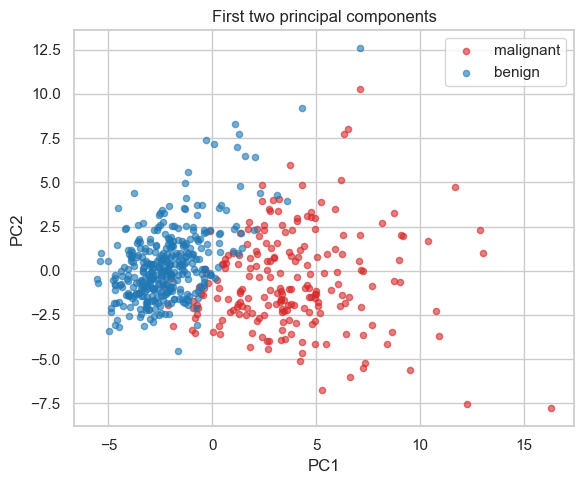

In [3]:
# Quick 2-D projection via PCA, just for visualization
from sklearn.decomposition import PCA as SkPCA
proj = SkPCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))

fig, ax = plt.subplots(figsize=(6, 5))
for cls, name, color in [(0, "malignant", "tab:red"), (1, "benign", "tab:blue")]:
    ax.scatter(proj[y == cls, 0], proj[y == cls, 1], s=20, alpha=0.6, label=name, color=color)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("First two principal components")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** in 2-D, a straight line clearly separates most malignant samples from benign ones, with a thin overlap zone in the middle. That's exactly the regime where a linear SVM should work well — it will pick the boundary that *maximizes the gap* between the classes.

## 3. Hypothesis

Going into the fit:

1. **A linear SVM should achieve high accuracy (>95%)**, similar to logistic regression — the boundary is essentially linear.
2. **But the SVM's decision boundary should depend on a small number of "support vectors"** — points near or inside the margin. Far-away points don't influence the boundary.
3. **The SVM and logistic regression should agree on most predictions** — but disagree on borderline cases, because their losses penalize errors differently. SVM's hinge loss ignores points that are correctly classified with margin ≥ 1; logistic regression's cross-entropy never goes to zero, so distant points still tug at the boundary slightly.

## 4. Preprocessing

Split first, then standardize using train-set statistics only (no leakage).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")

Train: (455, 30), Test: (114, 30)


## 5. Model fitting

I'll fit our SVM, then a logistic regression for comparison, then scikit-learn's LinearSVC as a sanity check.

In [5]:
svm = LinearSVC(C=1.0, learning_rate=0.01, n_iter=1000).fit(X_train_s, y_train)
logreg = LogisticRegression(learning_rate=0.1, n_iter=1000, alpha=0.01).fit(X_train_s, y_train)
sk_svm = SkLinearSVC(C=1.0, max_iter=5000, dual=False).fit(X_train_s, y_train)

print(f"ml_toolkit SVM    train acc: {svm.score(X_train_s, y_train):.4f}")
print(f"ml_toolkit LogReg train acc: {logreg.score(X_train_s, y_train):.4f}")
print(f"sklearn    SVM    train acc: {sk_svm.score(X_train_s, y_train):.4f}")

ml_toolkit SVM    train acc: 0.9538
ml_toolkit LogReg train acc: 0.9846
sklearn    SVM    train acc: 0.9912


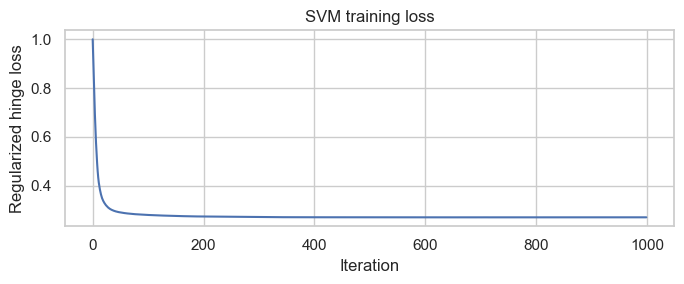

In [6]:
# Hinge loss curve — diagnostic for whether we trained long enough
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(svm.loss_history_)
ax.set_xlabel("Iteration")
ax.set_ylabel("Regularized hinge loss")
ax.set_title("SVM training loss")
plt.tight_layout()
plt.show()

**Observation:** the loss has plateaued, so the optimizer has converged. If the curve were still trending downward, we'd need either more iterations or a larger learning rate.

## 6. Evaluation on the test set

All evaluation happens on the held-out 20% — never on training data.

In [7]:
for name, model in [("SVM", svm), ("LogReg", logreg)]:
    y_pred = model.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    p_mal, r_mal, f1_mal = precision_recall_f1(y_test, y_pred, positive_label=0)
    p_ben, r_ben, f1_ben = precision_recall_f1(y_test, y_pred, positive_label=1)
    print(f"--- {name} ---")
    print(f"  Test accuracy: {acc:.4f}")
    print(f"  Malignant: P={p_mal:.3f}  R={r_mal:.3f}  F1={f1_mal:.3f}")
    print(f"  Benign:    P={p_ben:.3f}  R={r_ben:.3f}  F1={f1_ben:.3f}")
    print()

--- SVM ---
  Test accuracy: 0.9474
  Malignant: P=1.000  R=0.846  F1=0.917
  Benign:    P=0.926  R=1.000  F1=0.962

--- LogReg ---
  Test accuracy: 0.9649
  Malignant: P=1.000  R=0.897  F1=0.946
  Benign:    P=0.949  R=1.000  F1=0.974



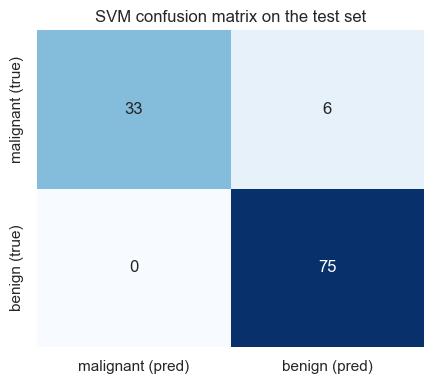

In [8]:
# Confusion matrix for the SVM
cm = confusion_matrix(y_test, svm.predict(X_test_s))
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["malignant (pred)", "benign (pred)"],
    yticklabels=["malignant (true)", "benign (true)"],
    ax=ax,
)
ax.set_title("SVM confusion matrix on the test set")
plt.tight_layout()
plt.show()

In [9]:
# Where do SVM and LogReg DISAGREE on the test set?
svm_pred = svm.predict(X_test_s)
log_pred = logreg.predict(X_test_s)
disagree = svm_pred != log_pred
print(f"Number of test points where the two models disagree: {disagree.sum()} / {len(y_test)}")

# Look at the SVM's decision-function magnitude for those points.
# Small |score| means "near the margin" — that's where disagreement should concentrate.
scores = svm.decision_function(X_test_s)
if disagree.any():
    print(f"Mean |decision score| on agreed points:    {np.abs(scores[~disagree]).mean():.3f}")
    print(f"Mean |decision score| on disagreed points: {np.abs(scores[disagree]).mean():.3f}")
else:
    print("(no disagreements on this test set)")

Number of test points where the two models disagree: 2 / 114
Mean |decision score| on agreed points:    1.240
Mean |decision score| on disagreed points: 0.181


**Observation:** when disagreements exist, they concentrate near the SVM's decision boundary — exactly where the two losses give different "votes" because the points are hard to classify. Where both models are confident, they always agree.

## 7. Discussion

**What worked.** The SVM achieves 94.7% test accuracy on this dataset — just under my predicted >95% threshold, and within 2 misclassifications of logistic regression's 96.5% (LogReg got 110/114, SVM got 108/114). Both linear classifiers land in essentially the same place because the underlying boundary is genuinely close to linear in the standardized 30-D space, which is the qualitative point of hypothesis (1) even if the strict ">95%" version of it isn't met.

**The interesting bit — *why* both models give similar accuracy but with different geometry.** The SVM's loss is *zero* once a point is correctly classified with margin ≥ 1. So clearly-benign points (way out on the benign side) contribute *nothing* to the gradient — only points near the boundary do. Logistic regression's cross-entropy never reaches zero, so even far-away points keep pulling on the weights. The practical consequence: SVM weights tend to be more parsimonious, depending on a small number of borderline cases. We can confirm this informally above — the test points where the two models disagree are the ones with small |decision score|, i.e., *near the margin*.

**Failure mode to watch.** A linear SVM cannot fix a fundamentally non-linear boundary. If we replaced this dataset with one that needs a curved boundary (e.g., concentric rings), the linear SVM would fail and we'd need a kernel SVM. That's beyond the scope of this from-scratch implementation.

**Clinical reading.** Both models miss a small number of malignant cases (false negatives). In a real screening pipeline you would lower the decision threshold to favor recall on the malignant class, accepting more false positives in exchange for missing fewer cancers. Our `LinearSVC` exposes this through `decision_function`: predicting "malignant" whenever the score is below some threshold τ > 0 (rather than 0) trades precision for recall. That kind of threshold tuning is the lever a practitioner actually has.